In [1]:
import duckdb
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns

sns.set_theme(style='darkgrid')
con = duckdb.connect('../data/cvm_fundos.duckdb')
print('Conexão OK')


Conexão OK


In [2]:
# Top 10 por Shape
df_ranking = con.execute('''
    SELECT nome_fundo, classe, sharpe_ratio,
           retorno_anualizado_pct, drawdown_maximo_pct, pl_milhoes
    FROM mart_ranking_fundos
    WHERE rank_geral <= 10
    ORDER BY rank_geral
''').df()

df_ranking

,nome_fundo,classe,sharpe_ratio,retorno_anualizado_pct,drawdown_maximo_pct,pl_milhoes
0,JGP MAGNUM MASTER FUNDO DE INVESTIMENTO FINANC...,Multimercado,13.08,9.766794e+05,-105.73,269.55
1,HASHDEX 100 NASDAQ CRYPTO INDEX FUNDO DE INVES...,Multimercado,13.01,1.272460e+05,-94.13,330.91
2,OCM OPPS BRAZIL FUNDO DE INVESTIMENTO MULTIMER...,Multimercado,11.44,3.776829e+08,-103.96,20.17
3,MT GLOBAL FUNDO DE INVESTIMENTO FINANCEIRO MUL...,Multimercado,9.59,1.967180e+05,-576.95,177.67
4,INDIE TEOREMA GLOBAL FUNDO DE INVESTIMENTO FIN...,Ações,9.44,5.699840e+04,-94.79,1.90
5,GROWTH NUMERIC UNLIMITED FUNDO DE INVESTIMENTO...,Multimercado,9.25,1.055700e+02,-1.51,1.40
6,GOLDEN SKY FUNDO DE INVESTIMENTO MULTIMERCADO ...,Multimercado,7.86,2.745000e+01,-0.04,29.44
7,KSK FUNDO DE INVESTIMENTO MULTIMERCADO CREDITO...,Multimercado,7.13,1.389900e+02,-3.40,126.37
8,ABIATAR FUNDO DE INVESTIMENTO EM COTAS DE FUND...,Multimercado,7.07,4.827000e+01,-0.77,133.27
9,JP MM FUNDO DE INVESTIMENTO MULTIMERCADO CRÉDI...,Multimercado,6.95,4.792000e+01,-0.07,550.65


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

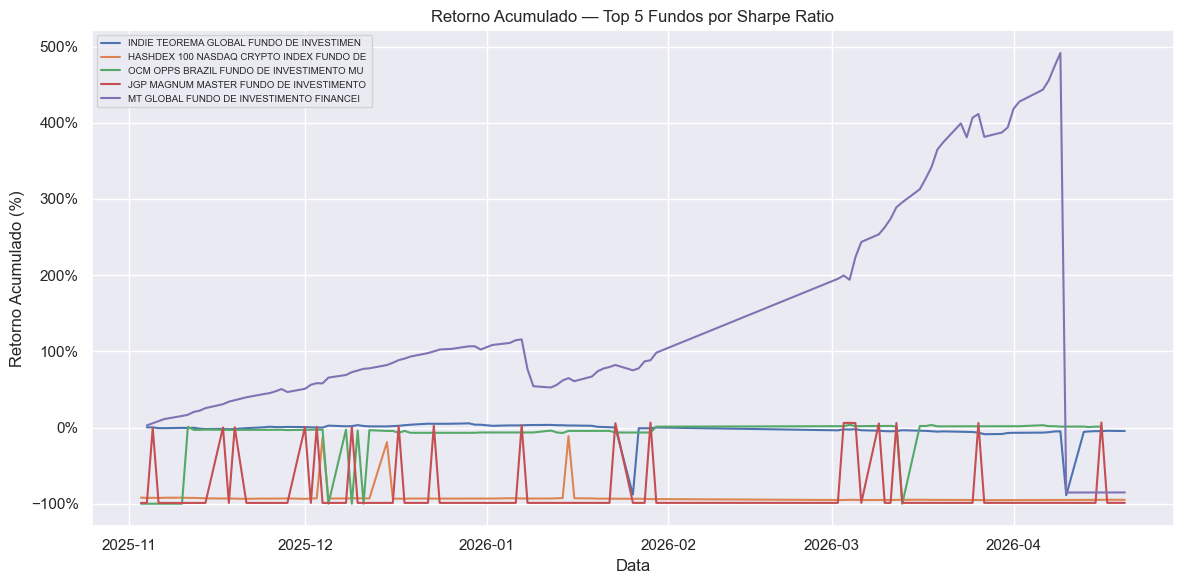

Gráfico salvo em docs/retorno_acumulado.png


In [3]:
# gráfico de retorno acumulado dos top 5 fundos:
top5 = con.execute('''
    SELECT cnpj_fundo FROM mart_ranking_fundos
    WHERE rank_geral <= 5
''').df()['cnpj_fundo'].tolist()

df_hist = con.execute(f'''
    SELECT data_competencia, cnpj_fundo, nome_fundo,
           exp(sum(ln(1 + retorno_diario)) over (
               partition by cnpj_fundo
               order by data_competencia
           )) - 1 as retorno_acumulado
    FROM int_cotas_historico
    WHERE cnpj_fundo IN ({str(top5)[1:-1]})
    ORDER BY cnpj_fundo, data_competencia
''').df()

fig, ax = plt.subplots(figsize=(12, 6))
for cnpj, grupo in df_hist.groupby('cnpj_fundo'):
    nome = grupo['nome_fundo'].iloc[0][:40]
    ax.plot(grupo['data_competencia'], grupo['retorno_acumulado'] * 100, label=nome)

ax.yaxis.set_major_formatter(mtick.PercentFormatter())
ax.set_title('Retorno Acumulado — Top 5 Fundos por Sharpe Ratio')
ax.set_xlabel('Data')
ax.set_ylabel('Retorno Acumulado (%)')
ax.legend(fontsize=7)
plt.tight_layout()
plt.savefig('../docs/retorno_acumulado.png', dpi=150)
plt.show()
print('Gráfico salvo em docs/retorno_acumulado.png')


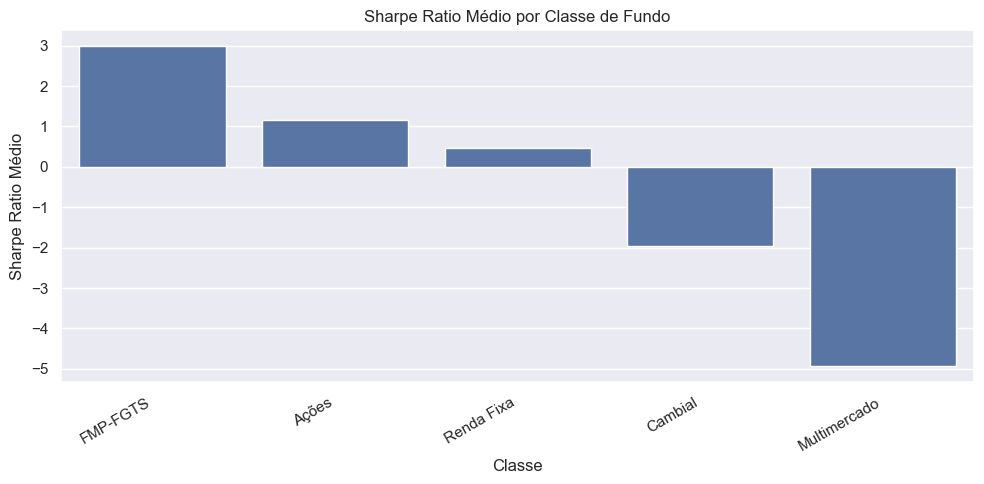

Gráfico salvo em docs/sharpe_por_classe.png


In [4]:
# distribuição de Sharpe por classe
df_classe = con.execute('''
    SELECT classe, COUNT(*) as fundos,
           round(AVG(sharpe_ratio), 2) as sharpe_medio
    FROM mart_ranking_fundos
    WHERE classe IS NOT NULL
    GROUP BY classe
    ORDER BY sharpe_medio DESC
''').df()

fig, ax = plt.subplots(figsize=(10, 5))
sns.barplot(data=df_classe, x='classe', y='sharpe_medio', ax=ax)
ax.set_title('Sharpe Ratio Médio por Classe de Fundo')
ax.set_xlabel('Classe')
ax.set_ylabel('Sharpe Ratio Médio')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.savefig('../docs/sharpe_por_classe.png', dpi=150)
plt.show()
print('Gráfico salvo em docs/sharpe_por_classe.png')